In [9]:
import torch
import ultralytics
import kagglehub

print("torch:", torch.__version__)
print("MPS is here", torch.backends.mps.is_available())

torch: 2.13.0
MPS is here True


In [10]:
from pathlib import Path

path = kagglehub.dataset_download("akinduhiman/urban-issues-dataset")
root = Path(path)
print("Dataset path:", root)

Dataset path: /Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19


In [11]:
potholes = root / "Potholes and RoadCracks"
print("Inside Potholes and RoadCracks:")
for p in sorted(potholes.iterdir()):
    print(" ", p.name)

Inside Potholes and RoadCracks:
  Potholes and RoadCracks


In [12]:
inner  = potholes / "Potholes and RoadCracks"
print("Inside Potholes and RoadCracks:")
for p in sorted(inner.iterdir()):
    print(" ", p.name)



Inside Potholes and RoadCracks:
  test
  train
  valid


In [13]:
innermain  = inner / "train"
print("Inside train:")
for p in sorted(innermain.iterdir()):
    print(" ", p.name)



Inside train:
  images
  labels
  labels.cache


In [14]:
images  = innermain / "images"
print("Inside images:")
imgs = sorted(images.iterdir())
print("number of images:", len(imgs))
for p in imgs[:5]:
    print(" ", p.name)


labels  = innermain / "labels"
print("Inside labels:")
lbls = sorted(labels.iterdir())
print("number of labels:", len(lbls))


Inside images:
number of images: 5667
  1-7-_jpg.rf.cd534274dc43f29782da16048504fad6.jpg
  100_jpg.rf.007bfbb6df4e5d8fcb83ce77f63fb11c.jpg
  100_jpg.rf.3a05a2a537ad06251dc4a5a1ca4bbf8b.jpg
  100_jpg.rf.3caf197d115db938f70442b9cbefbe34.jpg
  100_jpg.rf.5554a3ecfb13f8c6a8c376d968ac3a9e.jpg
Inside labels:
number of labels: 5667


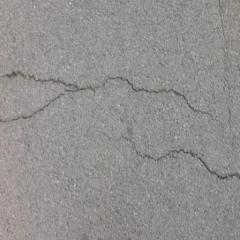

In [15]:
from IPython.display import Image, display
display(Image(imgs[0]))

In [16]:
print((labels / (imgs[0].stem + ".txt")).read_text())


0 0 0.5256614916666666 0.9421107333333333 0.5238763458333333 0.9438962458333333 0.28109291666666664 0 0.27752255833333334 0 0.5256614916666666
0 1 0.5810018791666667 0.5171842958333334 0.5863575166666667 0.5243258083333333 0.7523784083333334 1 0.7470230416666667 1 0.5810018791666667



In [17]:
yaml_path = Path("potholes_data.yaml")

yaml_path.write_text(f"""
path: {inner.resolve()}
train: train/images
val: valid/images
test: test/images
names:
  0: Damaged Road issues
  1: Pothole Issues
""")
print(yaml_path.read_text())
print(yaml_path.resolve())





path: /Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/Potholes and RoadCracks/Potholes and RoadCracks
train: train/images
val: valid/images
test: test/images
names:
  0: Damaged Road issues
  1: Pothole Issues

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/potholes_data.yaml


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data = str(yaml_path.resolve()),
    epochs = 6,
    imgsz = 640,
    batch = 16,
    device = "mps",
    project = "runs",
    name = "potholesv1",
)

In [ ]:
weights = Path("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv1/weights/best.pt")

print(weights.exists())  # should be True

In [ ]:
from ultralytics import YOLO

model = YOLO(str(weights))

results = model.train(
    data=str(yaml_path.resolve()),
    epochs=40,
    patience=15,
    imgsz=640,
    batch=16,
    device="mps",
    project="runs",
    name="potholesv2",
    save = True,
    plots = True,
    exist_ok = False,
    workers = 8
)

In [ ]:
from ultralytics import YOLO

model = YOLO("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv2/weights/last.pt")
results = model.train(resume=True)

In [19]:
# after HF login / acceptance
hf = YOLO("cazzz307/Pothole-Finetuned-YoloV8")
ours = YOLO(".../potholesv2/weights/best.pt")

hf.predict("test.jpg", conf=0.4, save=True)
ours.predict("test.jpg", conf=0.4, save=True)

FileNotFoundError: 'cazzz307/Pothole-Finetuned-YoloV8' does not exist

In [20]:
from ultralytics import YOLO

model = YOLO("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv2/weights/best.pt")

results = model.train(
    data=str(yaml_path.resolve()),  # same yaml as before
    epochs=40,          # another 40 (or 30)
    patience=20,        # stop if it truly flats out
    imgsz=640,
    batch=16,
    device="mps",
    project="runs",
    name="potholesv3",
    workers=4,
    resume=True
)

WARNING ⚠️ model '/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv2/weights/best.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.112 🚀 Python-3.12.7 torch-2.13.0 MPS (Apple M5)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/nehasaboo/StudioProjects/street_sync/yolomodel/potholes_data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fract

/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       1/40      4.29G      1.771      1.453      1.567         60        640: 100% ━━━━━━━━━━━━ 355/355 1.0it/s 5:430.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 29.8s0.7ss
                   all       1219       3165      0.548      0.495      0.496       0.22

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

       2/40      4.28G      1.843      1.537      1.609          4        640: 100% ━━━━━━━━━━━━ 355/355 1.1it/s 5:380.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 29.8s0.7ss
                   all       1219       3165      0.529      0.437      0.449      0.196

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      38/40      4.28G      1.612       1.11      1.466          9        640: 100% ━━━━━━━━━━━━ 355/355 1.1it/s 5:380.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.2it/s 32.4s0.8ss
                   all       1219       3165      0.663      0.542      0.595      0.277

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

      39/40      4.31G        1.6      1.096      1.461          5        640: 100% ━━━━━━━━━━━━ 355/355 1.0it/s 5:380.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 30.6s0.8ss
                   all       1219       3165      0.645      0.559      0.598       0.28

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: scatter_reduce_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:190.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
/Users/nehasaboo/StudioProjects/street_sync/yolomodel/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: index_put_with_accumulate_mps does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support f

      40/40      4.31G      1.595      1.092      1.453          7        640: 100% ━━━━━━━━━━━━ 355/355 1.1it/s 5:360.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.3it/s 30.4s0.8ss
                   all       1219       3165      0.663      0.553      0.604      0.282

40 epochs completed in 4.235 hours.
Optimizer stripped from /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv3-2/weights/last.pt, 6.2MB
Optimizer stripped from /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv3-2/weights/best.pt, 6.2MB

Validating /Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv3-2/weights/best.pt...
Ultralytics 8.4.112 🚀 Python-3.12.7 torch-2.13.0 MPS (Apple M5)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 1.5it/s 25.2s

In [ ]:
from ultralytics import YOLO
from pathlib import Path

model = YOLO("/Users/nehasaboo/StudioProjects/street_sync/runs/detect/runs/potholesv3-2/weights/best.pt")

img = "/Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/Potholes and RoadCracks/Potholes and RoadCracks/valid/images/1016_jpg.rf.ce49dbaaf9931f3e856499b9e7ce048d.jpg"

results = model.predict(
    source=img,
    conf=0.1,      # try 0.4 / 0.5 / 0.55
    iou=0.5,
    device="mps",
    save=True,      # writes annotated image
)

# where it saved
print(results[0].save_dir)

# quick summary
for r in results:
    if r.boxes is None or len(r.boxes) == 0:
        print("No detections")
        continue
    for box in r.boxes:
        cls_id = int(box.cls[0])
        conf = float(box.conf[0])
        name = r.names[cls_id]
        print(f"{name}: {conf:.2f}")


image 1/1 /Users/nehasaboo/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/Potholes and RoadCracks/Potholes and RoadCracks/valid/images/1016_jpg.rf.ce49dbaaf9931f3e856499b9e7ce048d.jpg: 640x640 (no detections), 13.0ms
Speed: 2.5ms preprocess, 13.0ms inference, 12.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /Users/nehasaboo/StudioProjects/street_sync/runs/detect/predict
/Users/nehasaboo/StudioProjects/street_sync/runs/detect/predict
No detections
